In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("./data/bike-sharing-demand/train.csv")
test_data = pd.read_csv("./data/bike-sharing-demand/test.csv")

### 1번 (기계학습): 자전거 대여 수요 예측 및 분류 (40점)

1.  **데이터 전처리:** `datetime` 컬럼을 활용하여 연, 월, 일, 시간, 요일 변수를 추출하고, 결측치 여부를 확인하여 적절한 처리 방안을 제시하시오.

In [2]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [3]:
train_data["datetime"]

0        2011-01-01 00:00:00
1        2011-01-01 01:00:00
2        2011-01-01 02:00:00
3        2011-01-01 03:00:00
4        2011-01-01 04:00:00
                ...         
10881    2012-12-19 19:00:00
10882    2012-12-19 20:00:00
10883    2012-12-19 21:00:00
10884    2012-12-19 22:00:00
10885    2012-12-19 23:00:00
Name: datetime, Length: 10886, dtype: object

In [4]:
train_data["datetime"] = pd.to_datetime(train_data["datetime"], format="%Y-%m-%d %H:%M:%S")

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [6]:
train_data["year"] = train_data["datetime"].dt.year
train_data["month"] = train_data["datetime"].dt.month
train_data["day"] = train_data["datetime"].dt.day
train_data["time"] = train_data["datetime"].dt.time
train_data["weekday"] = train_data["datetime"].dt.weekday

In [7]:
train_data.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
year          0
month         0
day           0
time          0
weekday       0
dtype: int64

2.  **변수 생성:** `count`(대여수) 변수를 바탕으로, 상위 25% 이상인 경우 'High'(1), 그렇지 않은 경우 'Low'(0)인 이진 분류용 종속변수 `demand_level`을 생성하시오.

In [8]:
train_data["count"].describe()
train_data["count"]>284

0        False
1        False
2        False
3        False
4        False
         ...  
10881     True
10882    False
10883    False
10884    False
10885    False
Name: count, Length: 10886, dtype: bool

In [9]:
train_data["demand_level"] = train_data["count"] >= train_data["count"].quantile(0.75)

In [10]:
sum(train_data["demand_level"])

2724

In [11]:
train_data["demand_level"].count()

10886

3.  **EDA 및 시각화:** 수치형 변수(기온, 습도 등)와 범주형 변수(계절, 날씨 등)를 분류하고, `demand_level`과의 관계를 나타내는 시각화를 3개 이상 수행한 뒤 그 결과를 해석하시오.

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      10886 non-null  datetime64[ns]
 1   season        10886 non-null  int64         
 2   holiday       10886 non-null  int64         
 3   workingday    10886 non-null  int64         
 4   weather       10886 non-null  int64         
 5   temp          10886 non-null  float64       
 6   atemp         10886 non-null  float64       
 7   humidity      10886 non-null  int64         
 8   windspeed     10886 non-null  float64       
 9   casual        10886 non-null  int64         
 10  registered    10886 non-null  int64         
 11  count         10886 non-null  int64         
 12  year          10886 non-null  int64         
 13  month         10886 non-null  int64         
 14  day           10886 non-null  int64         
 15  time          10886 non-null  object

In [13]:
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'day', 'time', 'weekday']
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
target = ['demand_level']

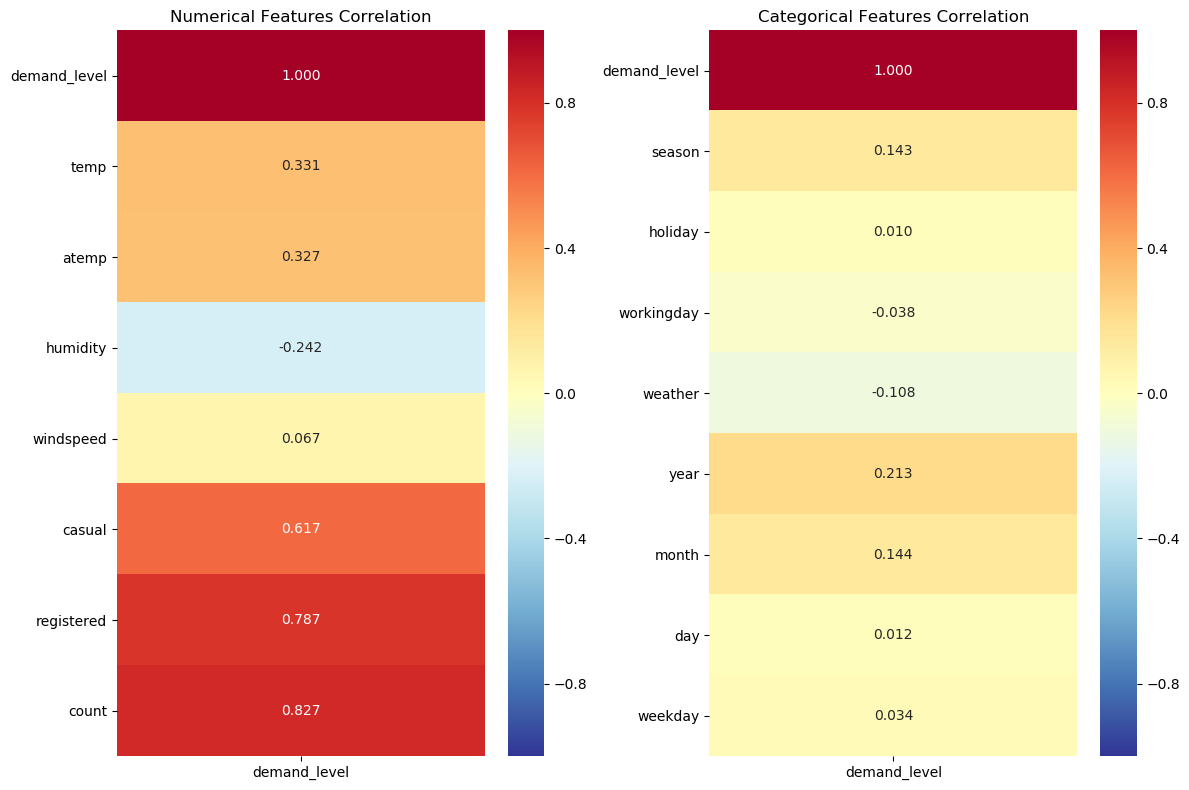

In [14]:
num_corr = train_data[target+num_cols].corr()
cat_corr = train_data[target+cat_cols].corr()

# 1. 캔버스 설정 (1행 2열)
# figsize는 전체 그림의 크기입니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# 2. 수치형 변수 히트맵 (첫 번째 칸: axes[0])
sns.heatmap(num_corr[target], 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlBu_r', 
            vmin=-1, vmax=1, 
            ax=axes[0])
axes[0].set_title('Numerical Features Correlation')

# 3. 범주형 변수 히트맵 (두 번째 칸: axes[1])
sns.heatmap(cat_corr[target], 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlBu_r', 
            vmin=-1, vmax=1, 
            ax=axes[1])
axes[1].set_title('Categorical Features Correlation')

# 레이아웃 간격 조정 및 출력
plt.tight_layout()
plt.show()

### 상관계수 분석 결과

1. 수치형 변수와 상관계수 비교 결과, 원래 연관된 변수였던 대여량 관련 값(casual, registered, count) 제외하면 온도, 습도가 대여량과 연관성이 높고, 풍속은 큰 영향이 없다는 것을 알 수 있다.
2. 범주형 변수와 비교 결과, 계절과 날씨가 그나마 상관계수가 높지만, 유의미하다고 할 정도는 아닌 것으로 보인다. 연도가 생각보다 높고, 그 다음으로 몇월인지가 높은데, 월의 경우 날씨와 관계성이 높아 수치가 이해되지만 연도는 명확한 상관관계가 이해되지 않으므로 추가 분석이 필요하다.

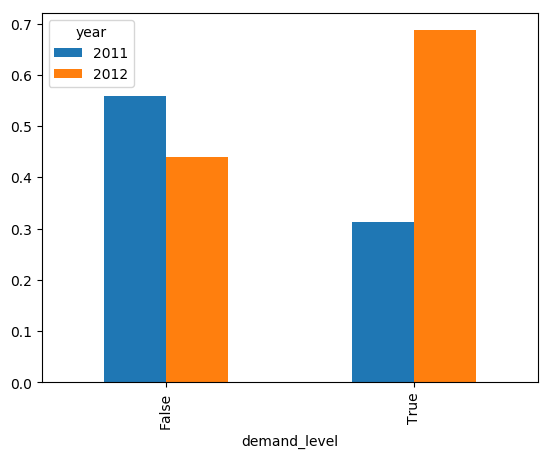

In [15]:
crasstab = pd.crosstab(train_data['demand_level'], train_data['year'], normalize = 'index')
crasstab.plot(kind='bar', stacked=False)
plt.show()

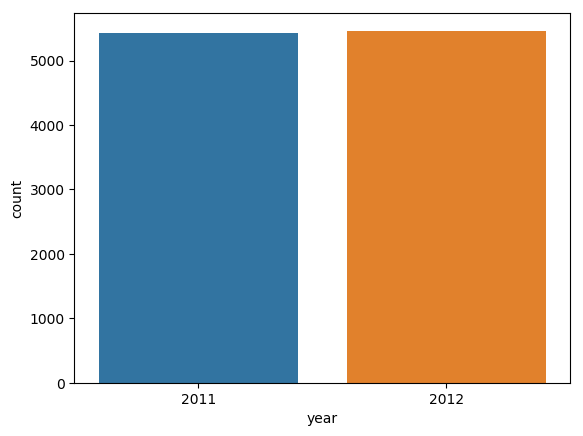

In [16]:
sns.countplot(train_data['year'])
plt.show()

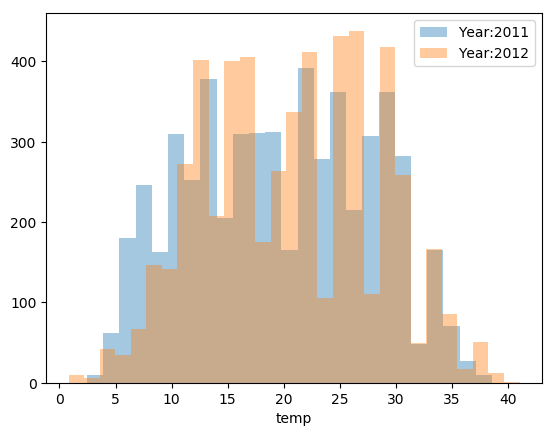

In [17]:
for year_value in [2011, 2012]:
    subset = train_data[train_data['year'] == year_value]
    sns.distplot(subset['temp'], hist=True, kde=False, label=f"Year:{year_value}")

plt.legend()
plt.show()

### 연도에 따른 대여량 분석 및 연도별 특징 분석

1. 전체적으로 12년도에 전체 대여량 중 25% 이상인 날이 몰려있는 것을 볼 수 있다.
2. 12년도 데이터가 상대적으로 많은지 확인해봤을 때, 그렇진 않음을 알 수 있다.
3. 대여량에 영향을 많이 미친 변수가 온도였던만큼, 12년도 온도가 11년도보다 높은지 확인해보았다. 결과적으로 20도 이상인 날이 좀 더 많은 것으로 보이긴하지만, 큰 차이가 날 정도는 아니다.
4. 외부 요인이 개입되었을 가능성이 높다. 단순히 공용 자전거 홍보량이 늘어나, 12년도에는 더 많은 사람이 인지하고 사용했을 가능성이 높다.

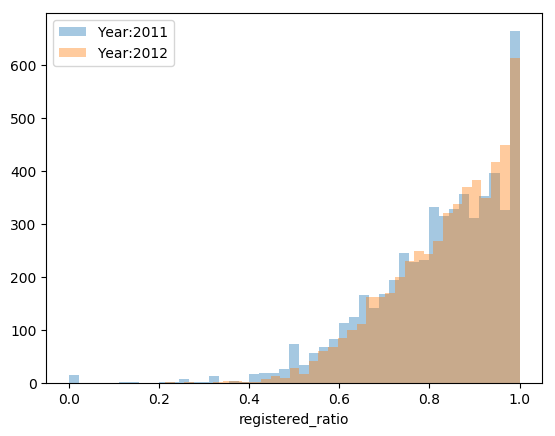

In [18]:
train_data['registered_ratio'] = train_data['registered']/train_data['count']
for year_value in [2011, 2012]:
    subset = train_data[train_data['year'] == year_value]
    sns.distplot(subset['registered_ratio'], hist=True, kde=False, label=f"Year:{year_value}")

plt.legend()
plt.show()

결국 전체 대여량 중 회원 대여량 기준으로 확인 결과, 12년에는 회원 대여량이 11년도에 비해 많은 것을 확인할 수 있다. 결국 자전거 대여에 대한 인지도가 늘어남에 따라 자연스레 12년의 자전거 대여량이 더 높다는 것을 알 수 있었다.

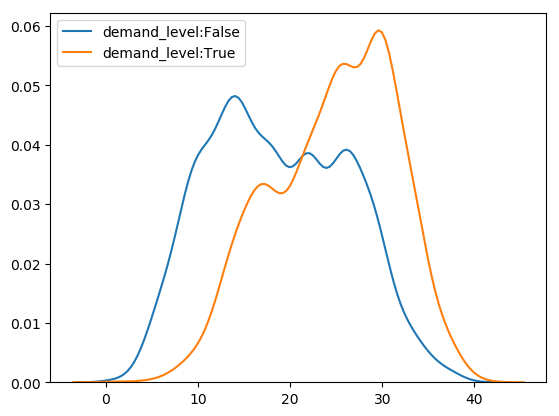

In [19]:
for label, group in train_data.groupby('demand_level'):
    sns.kdeplot(group['temp'], label=f"demand_level:{label}")
plt.legend()
plt.show()

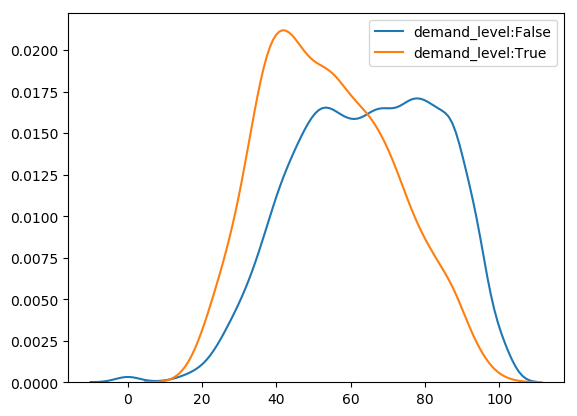

In [20]:
for label, group in train_data.groupby('demand_level'):
    sns.kdeplot(group['humidity'], label=f"demand_level:{label}")
plt.legend()
plt.show()

온습도에 따른 자전거 대여량의 경우, 눈에 띌 정도로 밀도함수에서 차이가 발생한 것을 볼 수 있다.
습도가 낮을수록 비가 오지 않은 날씨라 높은 대여량이 많이 몰린 것을 볼 수 있다.
특이한건 온도인데, 30도가 넘어가는 날씨에서 대여량이 가장 높다는 것이다. 해당 날씨의 습도를 비교해봐야 알겠지만, 아마 해당 시기가 습도가 낮아서 그럴 가능성도 높다고 생각된다.

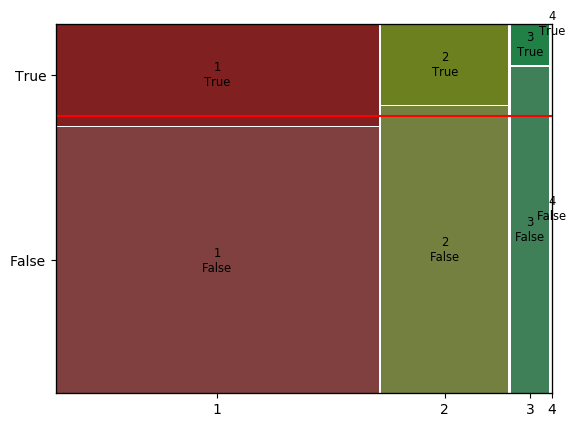

In [21]:
# 모자이크 플롯은 statsmodels에서 불러와야 한다. mosaic(dataframe, [feature, target])
from statsmodels.graphics.mosaicplot import mosaic
# Pclass별 생존여부를 mosaic plot으로 그리기
mosaic(train_data, ['weather','demand_level'])
plt.axhline(1-train_data['demand_level'].mean(), color = 'r')
# 파일 내부 그래프 전체의 default 사이즈를 변경해주는 함수
plt.rcParams["figure.figsize"] = (12, 12)
# mosaic plot은 기존의 방식으로 그래프 크기 변경을 못하여 위와 같은 식으로 변경해야함
plt.show()

날씨에 따른 대여량 비교로, 1이 깨끗한 날씨, 2가 안개 구름, 3이 약간의 눈, 비, 4가 아주 많은 비와 우박이라고 한다.
그렇기에 4번은 데이터 자체도 적고, 대여량 자체도 높지 않은 것을 볼 수 있다.
전체적으로 1에 가까울수록 높은 대여량을 보이기에 유의미한 변수라고 생각할 수 있다.

4.  **변수 선택:** `demand_level`과 상관관계가 높은 수치형 변수 2개와 범주형 변수 2개를 선정하고, 다중공선성(VIF) 문제를 검토하시오.

#### 높은 수치형 변수 : `temp`, `atemp`
#### 높은 범주형 변수 : `season`, `month`
  - `year` 제외 : `year`는 외부 요인 개입으로 인한 증가라고 가정하여, 우선 제외하는 방향으로 진행

In [22]:
num_corr_var = num_corr["temp"]["atemp"]
cat_corr_var = cat_corr["season"]["month"]
print("수치형 변수 간 다중공선성 체크를 위한 상관계수:", num_corr_var)
print("범주형 변수 간 다중공선성 체크를 위한 상관계수:", cat_corr_var)

수치형 변수 간 다중공선성 체크를 위한 상관계수: 0.9849481104817348
범주형 변수 간 다중공선성 체크를 위한 상관계수: 0.971523799632481


측정온도와 체감온도 관계가 있을 수 밖에 없는만큼, 상관계수가 0.98로 굉장히 높다.
계절과 몇월인지는 얼마나 세분화되어 있냐에 차이라서, 이 또한 상관계수가 0.97로 굉장히 높다.
즉, 실제 머신러닝 단계에서는 데이터 전처리할 때 이 두 값 중 하나는 제거해야 예측 결과가 한결 정확하게 나올 수 있다.

5.  **모델링:** 단일 알고리즘(예: Decision Tree)과 앙상블 알고리즘(예: Random Forest 또는 XGBoost)을 각각 학습시키고, 하이퍼파라미터 튜닝 과정을 설명하시오.

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

y_data = train_data[target]
x_data = train_data.drop(target, axis=1)
x_data = x_data.drop(["datetime", "atemp", "casual", "registered", "count", "season", "year", "registered_ratio"], axis=1)
x_data["time"] = x_data['time'].apply(lambda x: x.hour)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data["demand_level"], test_size=0.2, stratify=y_data["demand_level"])

In [67]:
dt_clf = DecisionTreeClassifier(max_depth=5)
dt_clf.fit(x_train, y_train)
dt_pred = dt_clf.predict(x_test)
print(f"{accuracy_score(y_test, dt_pred):.3f}")

0.844


In [68]:
rt_clf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=1)
rt_clf.fit(x_train, y_train)
rt_pred = rt_clf.predict(x_test)
print(f"{accuracy_score(y_test, rt_pred):.3f}")

0.852


공분산성이 높거나, count라는 target을 생성하는데 직접적으로 관여한 변수, 외부 요인으로 인한 관계량에 변화를 가진 변수 등을 x_data에서 제거합니다. 하이퍼파라미터의 경우 대중적으로 많이 사용하는 값을 기준으로 진행합니다.

6.  **평가:** Confusion Matrix와 F1-score를 사용하여 두 모델의 성능을 비교하고, 최종 모델을 선정한 사유를 서술하시오.

In [71]:
from sklearn.metrics import f1_score, confusion_matrix

print(f"{f1_score(y_test, dt_pred):.4f}")
print(f"{f1_score(y_test, rt_pred):.4f}")

print(f"{confusion_matrix(y_test, dt_pred)}")
print(f"{confusion_matrix(y_test, rt_pred)}")

0.6593
0.5978
[[1509  124]
 [ 216  329]]
[[1615   18]
 [ 305  240]]


F1 점수나, 혼동행렬로 확인해보면 단일 알고리즘인 트리 알고리즘이 일반 상황에서 더욱 유효하게 사용 가능한 것을 알 수 있다. 전체 정확도는 미세하게 랜덤 포레스트가 더 높지만, 랜덤 포레스트의 경우 FN이 높은 경향이 있습니다. 즉, 정밀도(Precision)가 높아야 하는 상황일 경우 유효하지만, 일반적인 상황, 현재 데이터와 같이 높은 수요가 요구되는 상황이 언제인지 맞춰야 하는 상황에서는 오히려 정확도가 떨어질 수 있습니다.

### 2번 (기계학습): 파생 변수 및 시계열 전처리 (20점)

**[전처리 가이드]**
* 주어진 데이터에는 `temp`(실제 기온)와 `atemp`(체감 기온)가 포함되어 있습니다.
* 두 변수의 차이(`diff_temp`)를 계산하여 새로운 변수를 생성하고, 이 변수가 대여량 예측에 유의미한지 산점도를 통해 확인하시오.
* 시간대별로 데이터가 정렬되어 있지 않다면, 시간 순서대로 정렬하고 3시간 단위의 이동평균(Moving Average) 대여량을 계산하여 파생 변수로 추가하시오.

### 3번 (통계분석): 시계열 분해 및 이상치 탐지 (20점)

1.  **시계열 분해:** 전체 대여량(`count`)에 대해 STL 분해를 수행하시오. (주기는 일일 단위인 24로 설정)

2.  **강도 계산:** 분해된 성분을 바탕으로 추세 강도(Trend Strength)와 계절성 강도(Seasonal Strength)를 계산하고, 이 데이터가 계절적 영향을 얼마나 강하게 받는지 해석하시오.

3.  **이상치 판별:** STL 분해 후 발생한 잔차(Remainder)에 대하여 다음 두 가지 기준을 적용하시오.
    * **Z-score:** 2.5 이상인 지점
    * **IQR:** $Q3 + 1.5 \times IQR$ 또는 $Q1 - 1.5 \times IQR$을 벗어나는 지점
    * 두 기준 모두 만족하는 날짜를 추출하고, 해당 날짜의 날씨(Weather) 변수와 연관 지어 이상치 발생 원인을 추론하시오.

### 4번 (통계분석): 가설 검정 (20점)

1.  **평균 차이 검정:** '평일(workingday=1)'과 '주말(workingday=0)'의 평균 자전거 대여량에 차이가 있는지 유의수준 0.05에서 검정하시오. (단, 정규성과 등분산성 가정을 먼저 확인하고 적절한 검정 방법을 선택할 것)

2.  **독립성 검정:** '날씨 상태(weather)'와 '계절(season)' 사이에 연관성이 있는지 카이제곱 검정을 통해 확인하고 결과를 해석하시오.

3.  **회귀 분석:** 기온(`temp`)과 습도(`humidity`)가 대여량(`count`)에 미치는 영향을 다중회귀분석을 통해 확인하고, 회귀 계수의 유의성을 검정하시오.